In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Define path relative to the project root
state_shp = Path("data") / "tl_2025_us_state" / "tl_2025_us_state.shp"

# Load U.S. state boundary data
state = gpd.read_file(state_shp)

state.head()

,REGION,DIVISION,STATEFP,STATENS,GEOID,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,1,2,36,01779796,36,0400000US36,NY,New York,00,G4000,A,122049344560,19256566831,+42.9133974,-075.5962723,"MULTIPOLYGON (((-74.72623 44.99486, -74.72257 ..."
1,4,8,32,01779793,32,0400000US32,NV,Nevada,00,G4000,A,284537074263,1839852286,+39.3310928,-116.6151469,"POLYGON ((-119.32418 41.99392, -119.32362 41.9..."
2,4,9,02,01785533,02,0400000US02,AK,Alaska,00,G4000,A,1479893380150,244326118163,+63.3473560,-152.8397334,"MULTIPOLYGON (((-167.55823 60.22436, -167.5567..."
3,9,0,60,01802701,60,0400000US60,AS,American Samoa,00,G4000,A,197759070,1307243751,-14.2668475,-170.6671854,"MULTIPOLYGON (((-168.22527 -14.53591, -168.224..."
4,1,1,50,01779802,50,0400000US50,VT,Vermont,00,G4000,A,23872664356,1030573104,+44.0589536,-072.6710173,"POLYGON ((-72.04187 44.15665, -72.0418 44.1566..."


In [3]:
# Define four Census regions
# Map each U.S. state to one of the four standard Census regions.
region_map = {
    # Northeast
    'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast',
    'New Hampshire': 'Northeast', 'Rhode Island': 'Northeast', 'Vermont': 'Northeast',
    'New Jersey': 'Northeast', 'New York': 'Northeast', 'Pennsylvania': 'Northeast',
    
    # Midwest
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Michigan': 'Midwest',
    'Ohio': 'Midwest', 'Wisconsin': 'Midwest', 'Iowa': 'Midwest',
    'Kansas': 'Midwest', 'Minnesota': 'Midwest', 'Missouri': 'Midwest',
    'Nebraska': 'Midwest', 'North Dakota': 'Midwest', 'South Dakota': 'Midwest',
    
    # South
    'Delaware': 'South', 'District of Columbia': 'South', 'Florida': 'South',
    'Georgia': 'South', 'Maryland': 'South', 'North Carolina': 'South',
    'South Carolina': 'South', 'Virginia': 'South', 'West Virginia': 'South',
    'Alabama': 'South', 'Kentucky': 'South', 'Mississippi': 'South',
    'Tennessee': 'South', 'Arkansas': 'South', 'Louisiana': 'South',
    'Oklahoma': 'South', 'Texas': 'South',
    
    # West
    'Arizona': 'West', 'Colorado': 'West', 'Idaho': 'West',
    'Montana': 'West', 'Nevada': 'West', 'New Mexico': 'West',
    'Utah': 'West', 'Wyoming': 'West', 'Alaska': 'West',
    'California': 'West', 'Hawaii': 'West', 'Oregon': 'West',
    'Washington': 'West'
}

In [4]:
# Define nine Census divisions
# Map each U.S. state to one of the nine standard Census divisions.
division_map = {
    # Division 1: New England
    "Connecticut": "New England",
    "Maine": "New England",
    "Massachusetts": "New England",
    "New Hampshire": "New England",
    "Rhode Island": "New England",
    "Vermont": "New England",

    # Division 2: Middle Atlantic
    "New Jersey": "Middle Atlantic",
    "New York": "Middle Atlantic",
    "Pennsylvania": "Middle Atlantic",

    # Division 3: East North Central
    "Illinois": "East North Central",
    "Indiana": "East North Central",
    "Michigan": "East North Central",
    "Ohio": "East North Central",
    "Wisconsin": "East North Central",

    # Division 4: West North Central
    "Iowa": "West North Central",
    "Kansas": "West North Central",
    "Minnesota": "West North Central",
    "Missouri": "West North Central",
    "Nebraska": "West North Central",
    "North Dakota": "West North Central",
    "South Dakota": "West North Central",

    # Division 5: South Atlantic
    "Delaware": "South Atlantic",
    "District of Columbia": "South Atlantic",
    "Florida": "South Atlantic",
    "Georgia": "South Atlantic",
    "Maryland": "South Atlantic",
    "North Carolina": "South Atlantic",
    "South Carolina": "South Atlantic",
    "Virginia": "South Atlantic",
    "West Virginia": "South Atlantic",

    # Division 6: East South Central
    "Alabama": "East South Central",
    "Kentucky": "East South Central",
    "Mississippi": "East South Central",
    "Tennessee": "East South Central",

    # Division 7: West South Central
    "Arkansas": "West South Central",
    "Louisiana": "West South Central",
    "Oklahoma": "West South Central",
    "Texas": "West South Central",

    # Division 8: Mountain
    "Arizona": "Mountain",
    "Colorado": "Mountain",
    "Idaho": "Mountain",
    "Montana": "Mountain",
    "Nevada": "Mountain",
    "New Mexico": "Mountain",
    "Utah": "Mountain",
    "Wyoming": "Mountain",

    # Division 9: Pacific
    "Alaska": "Pacific",
    "California": "Pacific",
    "Hawaii": "Pacific",
    "Oregon": "Pacific",
    "Washington": "Pacific",
}

In [5]:
# Assign each state to a Census region and a division.
state['region'] = state['NAME'].map(region_map)
state['division'] = state['NAME'].map(division_map)
state[["NAME", "region", "division"]].head(10)

,NAME,region,division
0,New York,Northeast,Middle Atlantic
1,Nevada,West,Mountain
2,Alaska,West,Pacific
3,American Samoa,NaN,NaN
4,Vermont,Northeast,New England
5,Connecticut,Northeast,New England
6,Delaware,South,South Atlantic
7,New Mexico,West,Mountain
8,North Carolina,South,South Atlantic
9,Wisconsin,Midwest,East North Central


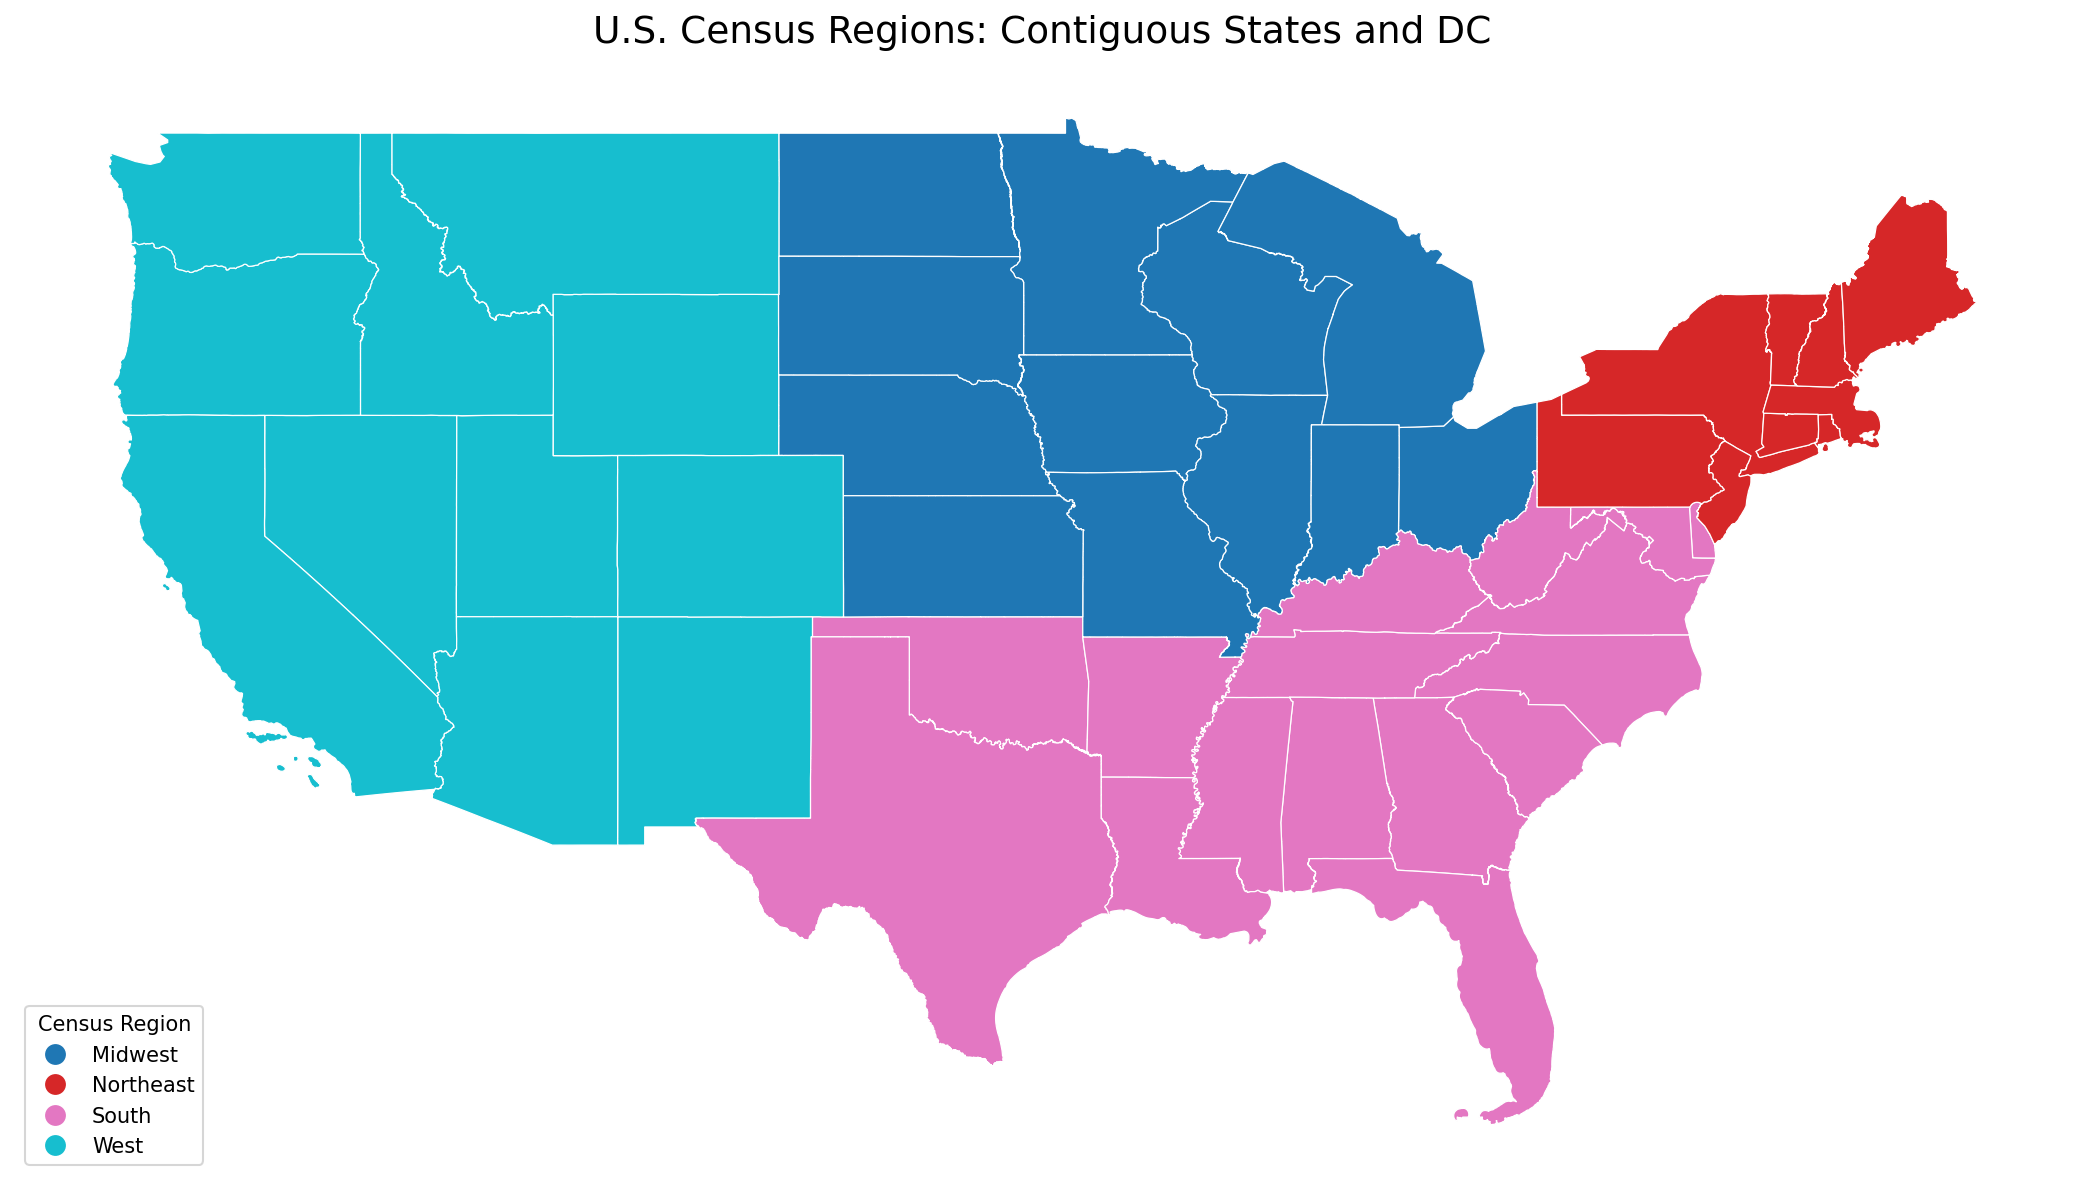

In [7]:
# For visualization, keep only the contiguous U.S. states and DC.
state_census = state.dropna(subset=["region", "division"]).copy()
# Alaska and Hawaii are valid Census states, but their locations create
# a very large map extent and make the mainland map appear small.
non_contiguous = ["Alaska", "Hawaii"]
state_lower48_dc = state_census[~state_census["NAME"].isin(non_contiguous)].copy()

# Create a large figure.
fig, ax = plt.subplots(figsize=(14, 9), dpi=150)

# Plot the contiguous U.S. states and DC by Census region.
state_lower48_dc.plot(
    column="region",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
    legend_kwds={
        "title": "Census Region",
        "loc": "lower left"
    }
)

# Add a title.
ax.set_title("U.S. Census Regions: Contiguous States and DC", fontsize=18, pad=12)

# Remove axis lines and tick labels.
ax.axis("off")

# Tighten the layout around the map.
plt.tight_layout()

# Display the figure.
plt.show()

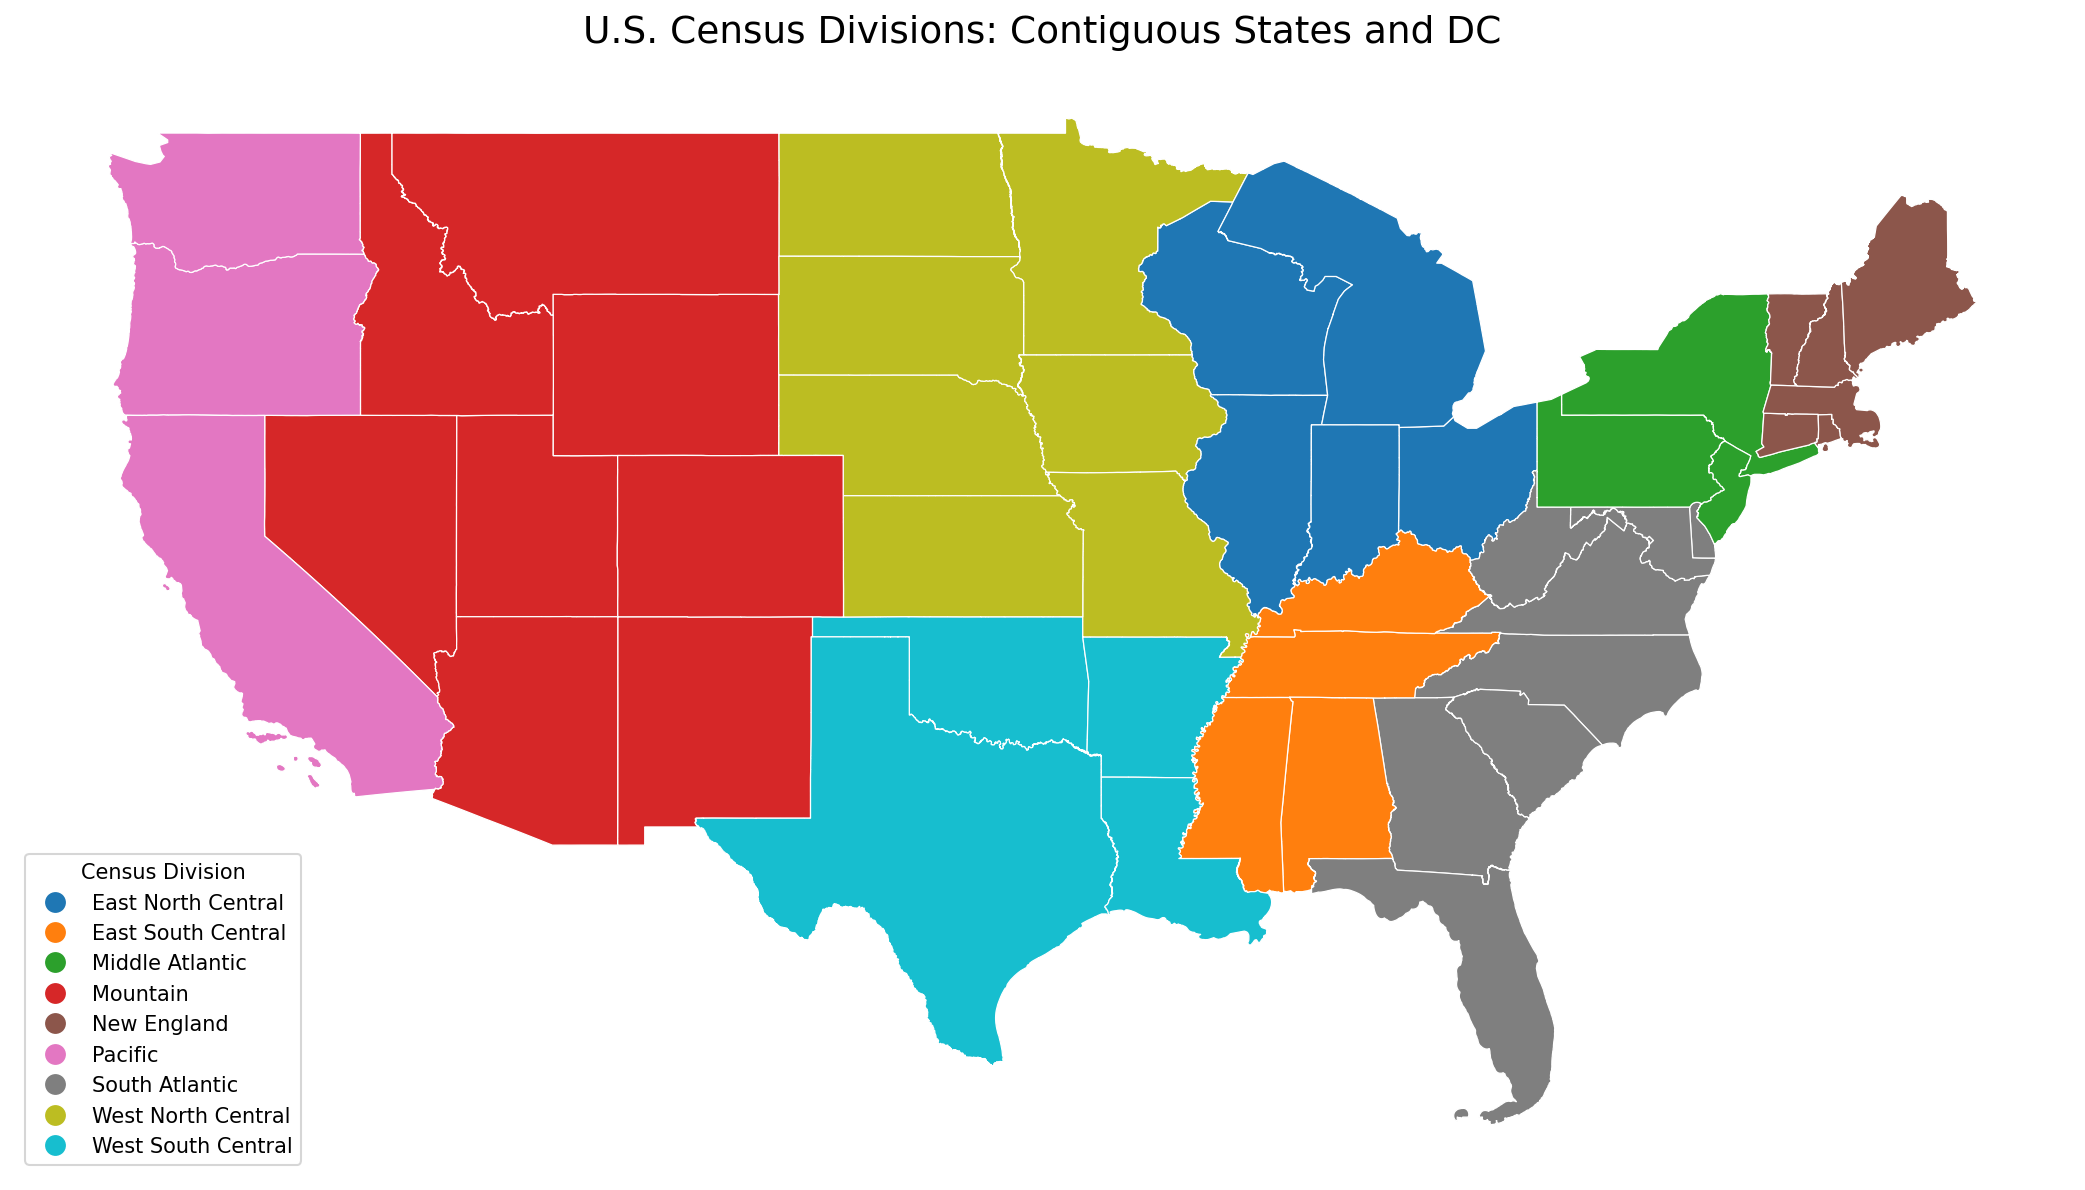

In [8]:
# Create a larger figure for the Census division map.
# The division map has more categories, so a larger figure helps readability.
fig, ax = plt.subplots(figsize=(14, 9), dpi=150)

# Plot the contiguous U.S. states and DC by Census division.
state_lower48_dc.plot(
    column="division",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
    legend_kwds={
        "title": "Census Division",
        "loc": "lower left"
    }
)

# Add a title.
ax.set_title("U.S. Census Divisions: Contiguous States and DC", fontsize=18, pad=12)

# Remove axis lines and tick labels.
ax.axis("off")

# Tighten the layout around the map.
plt.tight_layout()

# Display the figure.
plt.show()

In [ ]:
# Create an output folder for the generated shapefiles.
# The folder will be created if it does not already exist.
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# Keep only states/DC that have Census region and division assignments.
# This removes territories that are not part of the standard Census
# region/division classification.
state_census = state.dropna(subset=["region", "division"]).copy()

# Dissolve state geometries into four Census region polygons.
# Each output row represents one Census region:
# Northeast, Midwest, South, or West.
census_regions = (
    state_census
    .dissolve(by="region", as_index=False)
    [["region", "geometry"]]
)

# Dissolve state geometries into nine Census division polygons.
# Each output row represents one Census division.
census_divisions = (
    state_census
    .dissolve(by="division", as_index=False)
    [["division", "geometry"]]
)

# Save the dissolved Census region shapefile.
# A shapefile is made of several files (.shp, .shx, .dbf, .prj, etc.),
# so each output is saved inside its own folder.
region_output = output_dir / "us_census_regions"
region_output.mkdir(exist_ok=True)

census_regions.to_file(
    region_output / "us_census_regions.shp",
    driver="ESRI Shapefile"
)

# Save the dissolved Census division shapefile.
division_output = output_dir / "us_census_divisions"
division_output.mkdir(exist_ok=True)

census_divisions.to_file(
    division_output / "us_census_divisions.shp",
    driver="ESRI Shapefile"
)

Saved Census region shapefile to: outputs\us_census_regions
Saved Census division shapefile to: outputs\us_census_divisions


,region,geometry
0,Midwest,"POLYGON ((-94.62462 36.99901, -94.62517 36.999..."
1,Northeast,"MULTIPOLYGON (((-74.48282 39.28414, -74.48695 ..."
2,South,"MULTIPOLYGON (((-80.18532 25.33851, -80.18697 ..."
3,West,"MULTIPOLYGON (((-168.05061 25.02587, -168.0465..."


,division,geometry
0,East North Central,"POLYGON ((-88.02892 37.79873, -88.02985 37.798..."
1,East South Central,"POLYGON ((-88.39593 30.15468, -88.40416 30.152..."
2,Middle Atlantic,"POLYGON ((-74.47731 39.28869, -74.48282 39.284..."
3,Mountain,"POLYGON ((-103.06472 32.27087, -103.06472 32.2..."
4,New England,"MULTIPOLYGON (((-71.67381 41.17885, -71.67281 ..."
5,Pacific,"MULTIPOLYGON (((-170.68245 25.52064, -170.6817..."
6,South Atlantic,"MULTIPOLYGON (((-83.0992 24.67053, -83.09369 2..."
7,West North Central,"POLYGON ((-91.41981 40.3779, -91.42017 40.3775..."
8,West South Central,"POLYGON ((-91.16607 33.00411, -91.16604 33.003..."


In [ ]:
# Create a crosswalk table linking each state/DC to its Census region and division.
# GEOID is the Census state FIPS code.
census_crosswalk = (
    state_census[["GEOID", "NAME", "region", "division"]]
    .rename(columns={
        "GEOID": "state_fips",
        "NAME": "state_name"
    })
    .sort_values("state_name")
    .reset_index(drop=True)
)

# Save the crosswalk table as a CSV file.
crosswalk_output = output_dir / "us_census_regions_divisions_crosswalk.csv"

census_crosswalk.to_csv(crosswalk_output, index=False)

print("Saved Census region/division crosswalk table to:", crosswalk_output)

Saved Census region/division crosswalk table to: outputs\us_census_regions_divisions_crosswalk.csv
